# Basic utils for Investing based on Indicators

## Imports

In [2]:
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt


import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import random
import plotly.express as px

# Attribution d'une graine.
random.seed(1)

torch.manual_seed(1)

%reload_ext autoreload
%autoreload 2

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Data reading and processing

In [3]:
pair = 'SOLUSDT'
timeframe = '5m'
type_data = 'Futures'

# Importation des données


data = pd.read_csv(f'../data/binance/{pair}_{timeframe}_{type_data}.csv', parse_dates=[0], index_col=0)
data

,Open,High,Low,Close,Volume,Qav,Trades,Taker_base_vol,Taker_quote_vol
Date,,,,,,,,,
2020-09-14 09:00:00,3.2002,4.9100,3.2002,3.3045,42698,1.426940e+05,640,15267,5.195271e+04
2020-09-14 09:05:00,3.3045,3.3974,3.2844,3.3497,51149,1.712361e+05,1152,28120,9.440854e+04
2020-09-14 09:10:00,3.3486,3.3576,3.3151,3.3393,23974,7.976511e+04,675,6843,2.276923e+04
2020-09-14 09:15:00,3.3443,3.4189,3.3353,3.3834,65640,2.223665e+05,1231,24917,8.447305e+04
2020-09-14 09:20:00,3.3855,3.4149,3.3709,3.3787,55165,1.865342e+05,825,11150,3.776340e+04
...,...,...,...,...,...,...,...,...,...
2024-09-04 19:35:00,133.0160,133.2070,132.5270,132.9030,173991,2.312146e+07,13635,64643,8.591545e+06
2024-09-04 19:40:00,132.9040,133.3170,132.7000,132.7360,72642,9.664593e+06,6799,36578,4.867733e+06
2024-09-04 19:45:00,132.7360,133.1360,132.7330,133.0310,43489,5.781083e+06,4668,24068,3.199412e+06


0.0018065334815211035


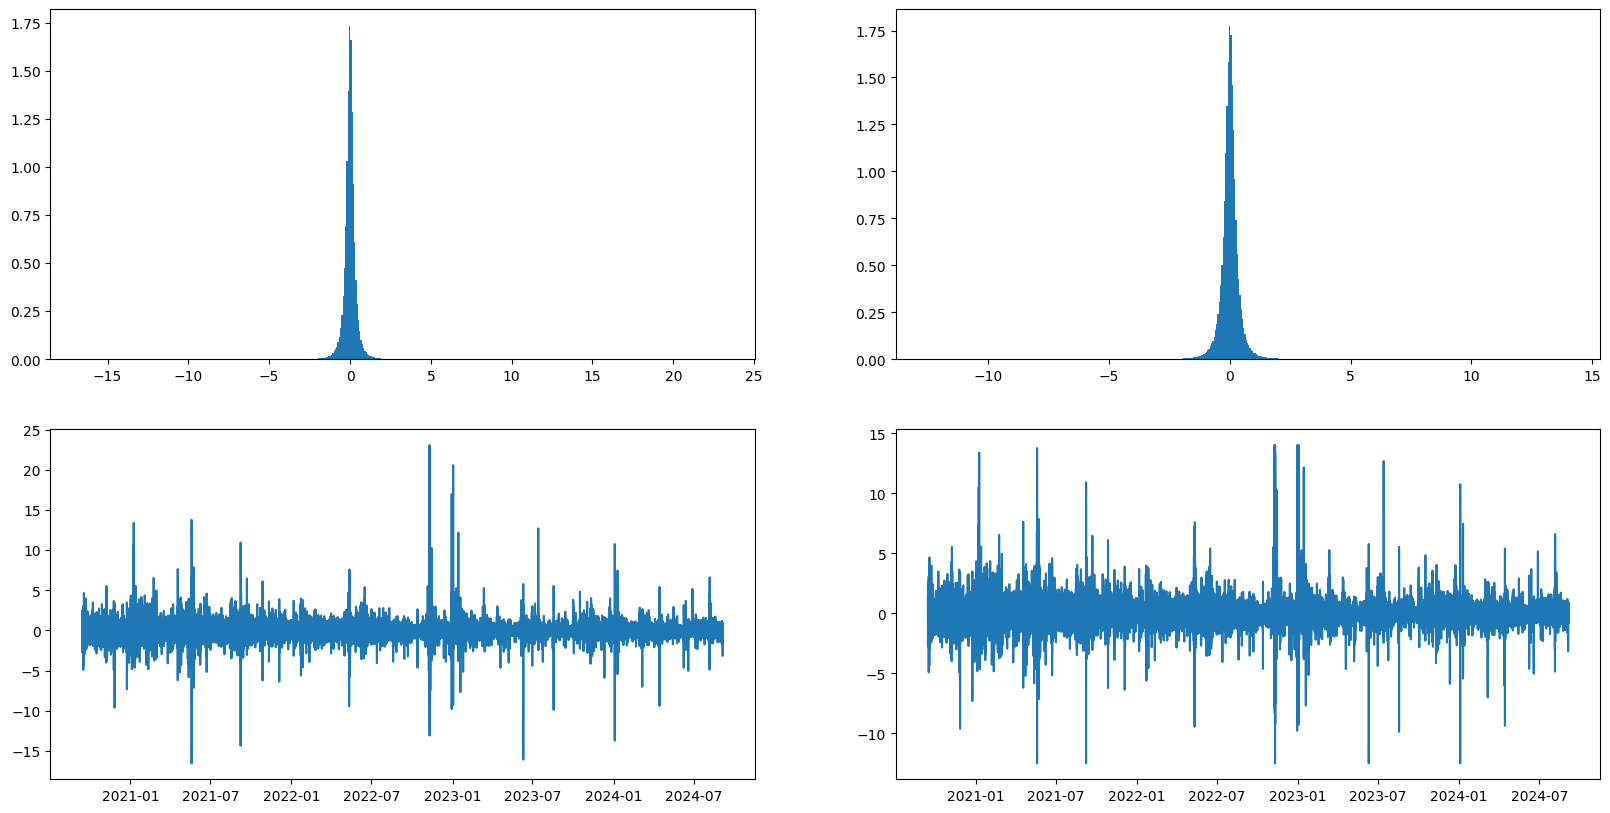

In [4]:
data.loc[:, '%R'] = data['Close'].pct_change()*100

df = data[['%R']].copy()

quatiles_threshold = 0.00001

plt.figure(figsize=(20, 10))

plt.subplot(2, 2, 1)    
plt.hist(df['%R'] , bins=500, density=True)

plt.subplot(2, 2, 3)
plt.plot(df['%R'])

df['%R'] = df['%R'].clip(lower=df['%R'].quantile(quatiles_threshold), upper=df['%R'].quantile(1-quatiles_threshold))

print(df['%R'].mean())

# df['%R'] = df['%R'] - df['%R'].mean()

plt.subplot(2, 2, 2)
plt.hist(df['%R'], bins=500, density=True)

plt.subplot(2, 2, 4)
plt.plot(df['%R'])

plt.show()

In [5]:
import ta

df.dropna(inplace=True)

In [6]:
df.describe()

,%R
count,418019.000000
mean,0.001807
std,0.431757
min,-12.507670
25%,-0.165888
50%,0.000000
75%,0.166059
max,14.022092


In [7]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

train_data, test_data = df[:int(len(data)*0.8)], df[int(len(data)*0.8):]

train_data = train_data.to_numpy()

test_data = test_data.to_numpy()

start_index = 0

train_target = train_data[:, :1]

test_target = test_data[:, :1]

print(f'k = {0}: train_target mean = {train_target.mean():.3E}, test_target mean = {test_target.mean():.3E}')

for k in range(1, 2):
    train_target = train_target - train_target.mean()
    test_target = test_target - test_target.mean()
    
    print(f'k = {k}: train_target mean = {train_target.mean():.3E}, test_target mean = {test_target.mean():.3E}')

scaler = StandardScaler()


train_data = scaler.fit_transform(train_data[:, start_index:]) 
test_data = scaler.transform(test_data[:, start_index:])

k = 0: train_target mean = 1.887E-03, test_target mean = 1.486E-03
k = 1: train_target mean = 2.890E-18, test_target mean = 8.658E-18


In [8]:
class ExpInvestLoss(nn.Module):
    def __init__(self, alpha=0.1):
        super(ExpInvestLoss, self).__init__()
        self.alpha = alpha

    def forward(self, y_pred, y_true):
        
        return torch.exp(-y_true*y_pred*self.alpha).mean()
    
class InvestLoss(nn.Module):
    def __init__(self, alpha=0):
        super(InvestLoss, self).__init__()
        self.alpha = alpha
    def forward(self, y_pred, y_true):
        
        r = y_true*y_pred
        
        return -r.mean()
    
class DiffInvestLoss(nn.Module):
    def __init__(self, fee=0.04):
        super(DiffInvestLoss, self).__init__()
        self.fee = fee
    def forward(self, inv, diff_inv, returns, leverage=0.1):
        if not self.fee == 0:
            
            gain = (inv*returns - self.fee * diff_inv.abs())/100*leverage
            
            # return -(1+gain).clamp(0).prod()/(torch.abs(torch.cumsum(gain, dim=0) - torch.arange(len(gain)).to(device)*gain.mean()).mean()+1e-5)
            return -(1+gain).clamp(0).prod()
        else:
            return -(1+inv*returns).prod()

In [9]:
src = torch.tensor(train_data[:-1], dtype=torch.float32).to(device)
tgt = torch.tensor(train_target[1:], dtype=torch.float32).to(device)

class Model(nn.Module):
    def __init__(self):
        super(Model, self).__init__()
        
        self.linear = nn.Linear(1, 1)
        
        self.tanh = nn.Tanh()


    def forward(self, x):
        return self.tanh(self.linear(x))
    
    
model = Model().to(device)

leverage = nn.Parameter(torch.tensor(-1., dtype=torch.float32))

criterion = DiffInvestLoss(fee=0.04)

optimizer = torch.optim.Adam(model.parameters(), lr=1e0, amsgrad=True, weight_decay=1e-7)

opt_leverage = torch.optim.Adam([leverage], lr=1e-2, amsgrad=True)

losses = []

a = []
b = []

print(model.linear.weight.item(), model.linear.bias.item())

for epoch in tqdm(range(1000)):
    model.train()
    optimizer.zero_grad()
    opt_leverage.zero_grad()

    a.append(model.linear.weight.item())
    b.append(model.linear.bias.item())
    
    inv= model(src).squeeze()
    
    diff_inv = torch.concat([torch.zeros((1)), inv]).diff()
    
    loss = criterion(inv, diff_inv, tgt.squeeze(), leverage=torch.exp(leverage))
    loss.backward()
    optimizer.step()

    
    losses.append(loss.item())
    
    if epoch % 100 == 0:
        print(f'Epoch {epoch}, loss {loss.item():.3E}')
        print(f'leverage {torch.exp(leverage).item()}')
        opt_leverage.step()

0.5152631998062134 -0.44137823581695557


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 0, loss -6.616E-08
leverage 0.3678794503211975
Epoch 100, loss -2.444E+00
leverage 0.36425158381462097
Epoch 200, loss -2.503E+00
leverage 0.3669722378253937
Epoch 300, loss -2.540E+00
leverage 0.37013962864875793
Epoch 400, loss -2.563E+00
leverage 0.37352994084358215
Epoch 500, loss -2.582E+00
leverage 0.3770642578601837
Epoch 600, loss -2.598E+00
leverage 0.38070523738861084
Epoch 700, loss -2.613E+00
leverage 0.38443177938461304
Epoch 800, loss -2.626E+00
leverage 0.3882308602333069
Epoch 900, loss -2.640E+00
leverage 0.3920934796333313


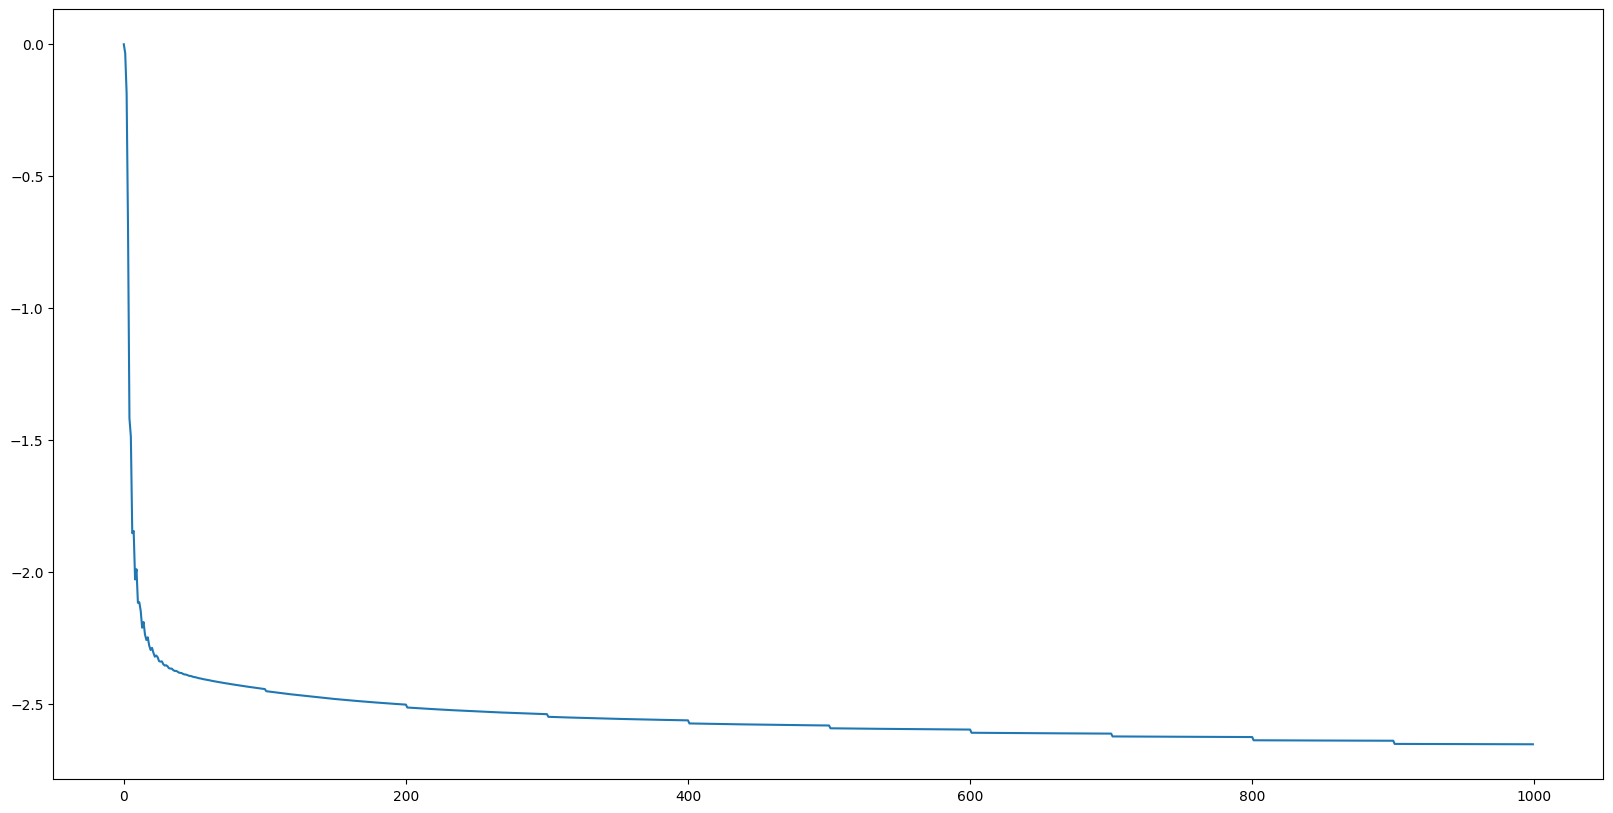

In [10]:
plt.figure(figsize=(20, 10))
plt.plot(losses)

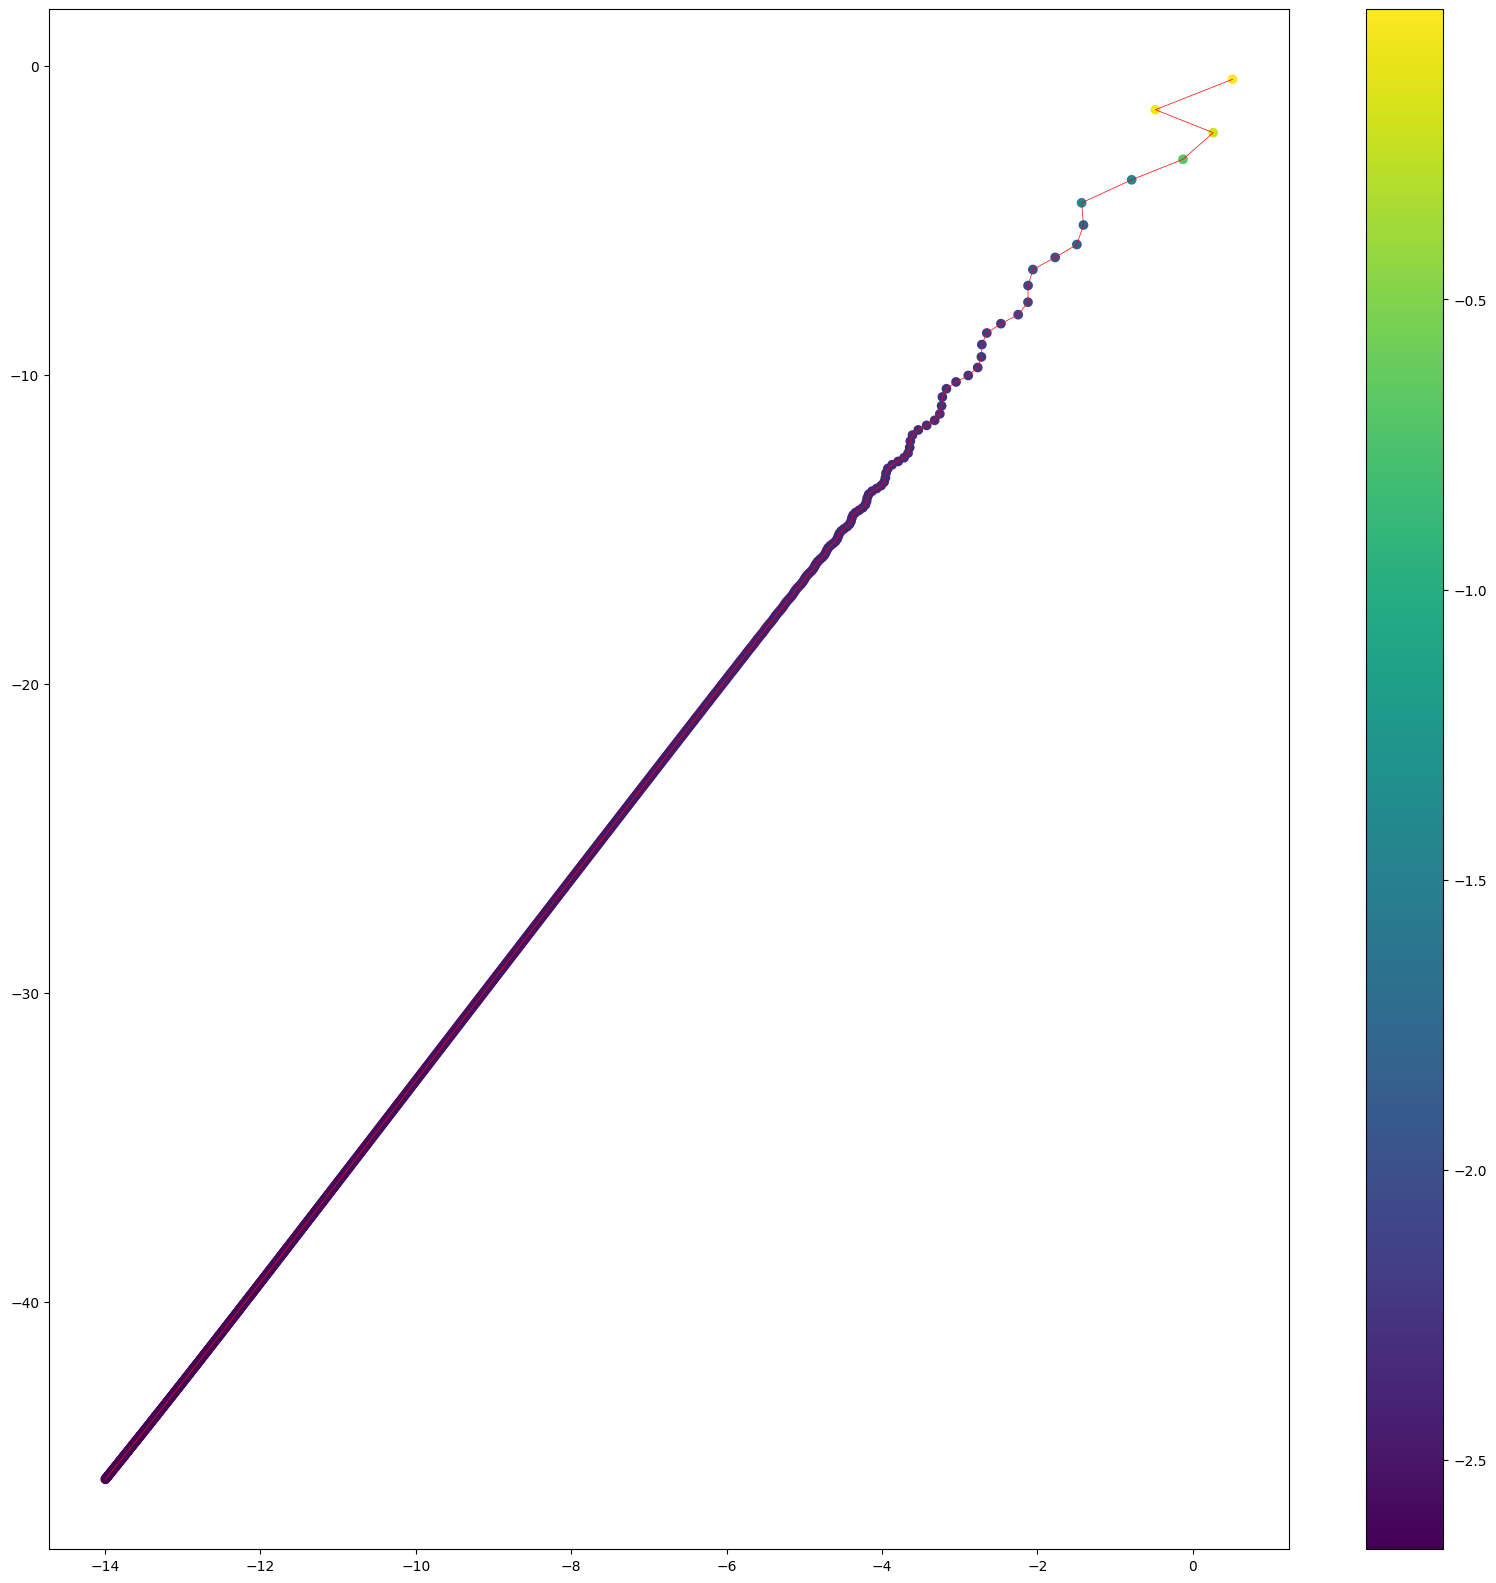

In [11]:
plt.figure(figsize=(20, 20))
plt.scatter(a, b, c=losses, cmap='viridis')
plt.colorbar()
plt.plot(a, b, c='red', lw=0.5)

In [164]:
import itertools

def ev(a,b, data):
    return torch.tanh(a*data + b)

a_grid = np.linspace(-10, 10, 101)
b_grid = np.linspace(-25, 25, 101)



def grid(grid_a, grid_b, data):
    
    score = []
    
    for a, b in itertools.product(grid_a, grid_b):
        inv = ev(a, b, data).squeeze()
        diff_inv = torch.cat([torch.zeros((1)), inv]).diff()
        loss = criterion(inv, diff_inv, tgt.squeeze(), torch.exp(leverage))+1e-7*(a**2 + b**2)
        score.append([a, b, -loss.item()])
    
    return np.array(score)

score = grid(a_grid, b_grid, src)

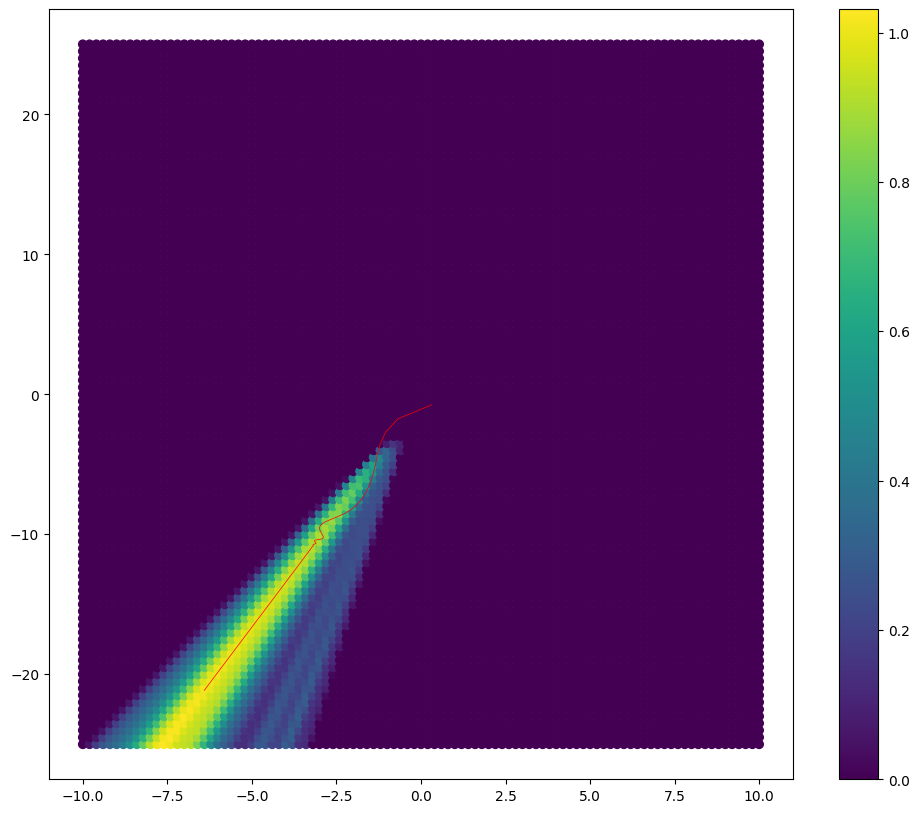

In [169]:
plt.figure(figsize=(12, 10))
plt.scatter(score[:, 0], score[:, 1], c=score[:, 2].clip(0), cmap='viridis')
plt.colorbar()

plt.plot(a, b, c='red', lw=0.5, )

In [166]:
max_a, max_b = score[np.argmax(score[:, 2])][:2]

print(max_a, max_b)

inv = ev(max_a, max_b, src).squeeze()

-7.6 -25.0


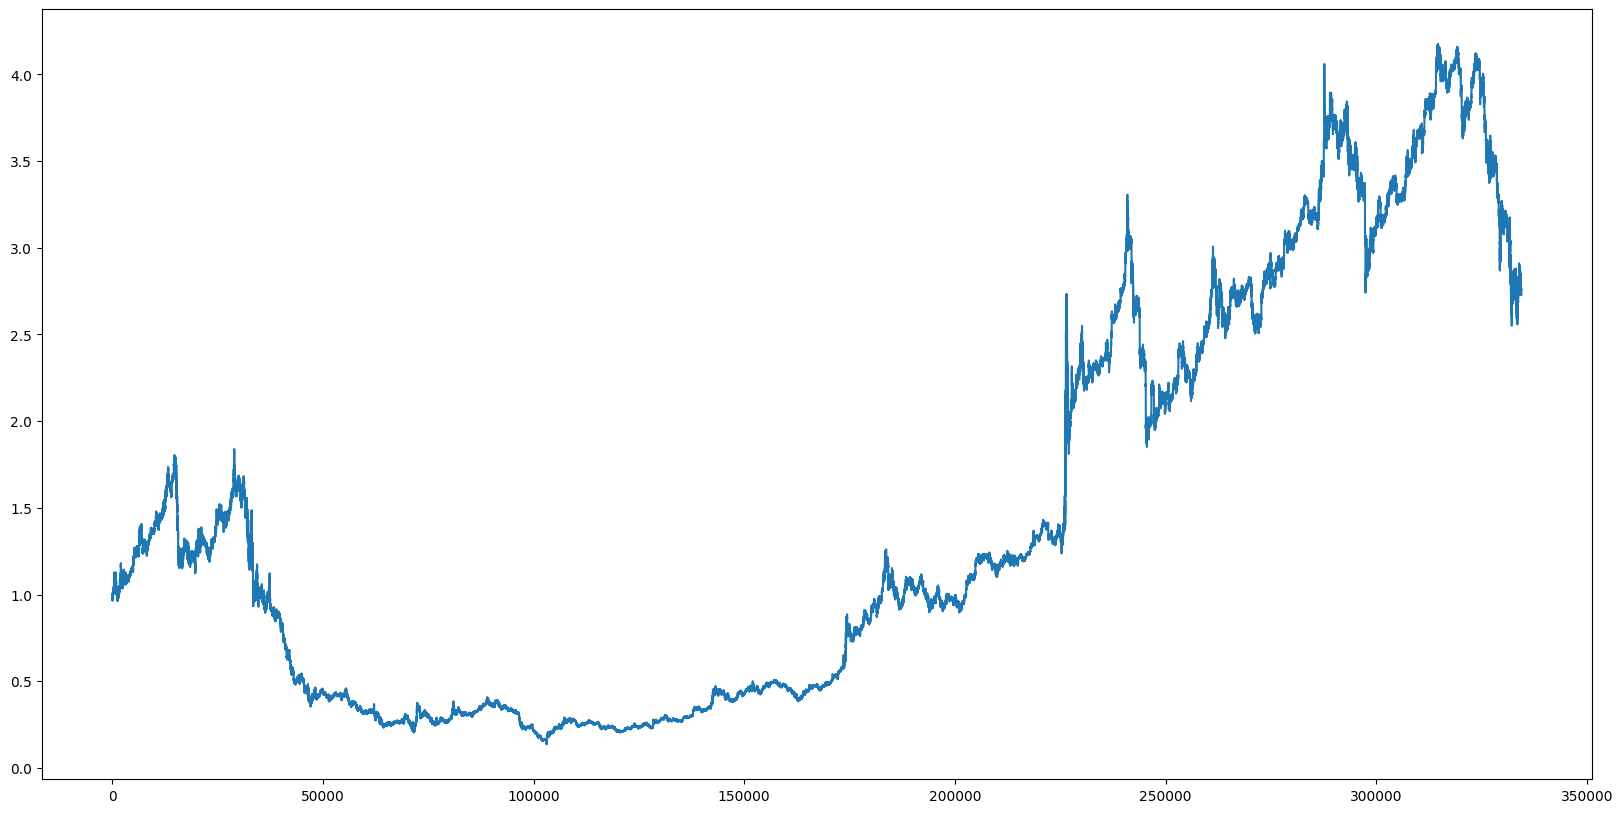

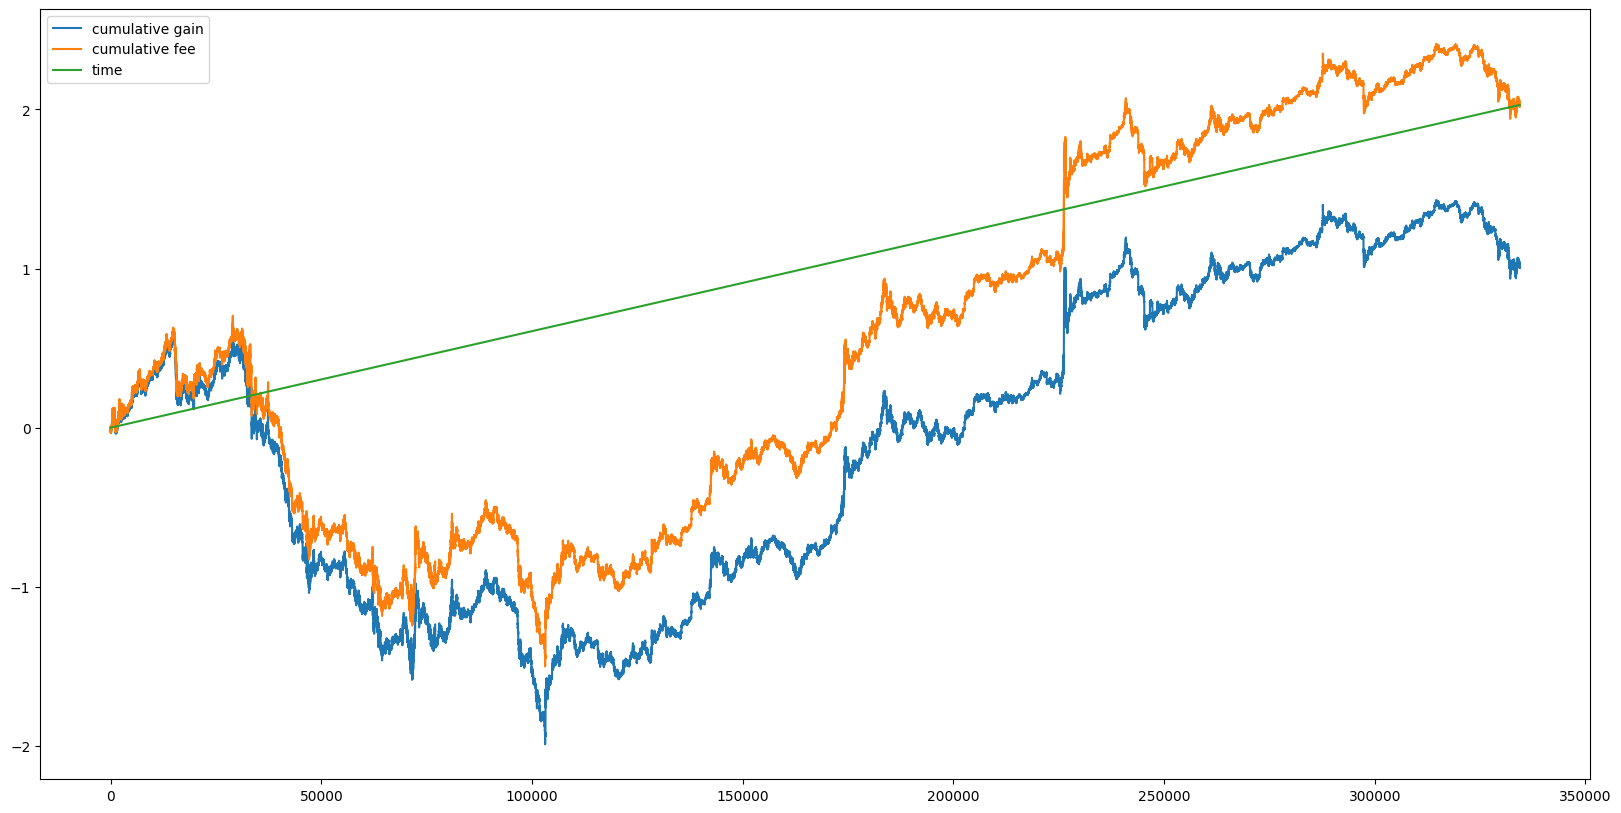

In [167]:
inv = model(src).squeeze()
diff_inv = torch.cat([torch.zeros((1)), inv]).diff()
returns = tgt.squeeze()

g_fee = ((inv*returns - criterion.fee * diff_inv.abs())/100*torch.exp(leverage).item()).cpu().detach().numpy()

gain = (1+g_fee).clip(0)

plt.figure(figsize=(20, 10))
plt.plot(gain.cumprod())
plt.show()
plt.figure(figsize=(20, 10))
plt.plot(np.log(gain.cumprod()), label='cumulative gain')
plt.plot(g_fee.cumsum(), label='cumulative fee')
plt.plot(np.arange(len(gain))*g_fee.mean(), label='time')
plt.legend()